In [ ]:
from importlib import reload
import torch
import numpy as np
import time
torch.set_default_dtype(torch.float64)
np.random.seed(2)
device = torch.device("cuda:1" if torch.cuda.is_available() else "cpu")
print(device)
import numpy as np
import sys #首先，添加路径，windows的路径和linux的路径符号不同\\,/,注意区别  #r是为了告诉python这是路径，别#把\n等特殊组合给转译）
sys.path.append(r"./main_code")
import generate_data2,grid_cell,adaptive_int,visual,cal_S_grad,org_m,mea_2D,net_2D_fix2,S_valgrad,error_general_2D,main,org_matrix_2D
CUDA_LAUNCH_BLOCKING=1


def f_circle(x,x_left,x_right,y_below,y_upper,center,r):
    # Compute r_y = sqrt((x1 - y1)^2 + (x2 - y2)^2 + (x3 - y3)^2)
    r_y = np.linalg.norm(x - center, axis=-1)
    # Apply the piecewise function
    f_y_values = np.where(r_y < r , 1.0, 0.0)
    return f_y_values

def f_rec(x,x_left,x_right,y_below,y_upper,center,r):
    cond= (x[:,0]>=x_left) & (x[:,0]<=x_right) & (x[:,1]>=y_below) & (x[:,1]<=y_upper)
    return cond*1

def ana_S(x,x_left,x_right,y_below,y_upper,center,r): #x为数据，a，b均为中心点
    return f_circle(x,x_left,x_right,y_below,y_upper,center,r)-f_rec(x,x_left,x_right,y_below,y_upper,center,r)


cuda:1


In [2]:
global Nx,Ny,kk,tau_x_min,tau_x_max,tau_y_min,tau_y_max,center,r
Nx = 1 # the number of sub-domains 
Ny = 1
M =800 #800 比 400 好
Qx = 29 # the number of collocation pointss per sub-domain 
Qy = 29
R_m=20
Qs=16
af="Tanh"
eps=0.05
kk=[1,5,9,13,17,21,25,29,33,37,41,45,49,53,57,61,65,69,73,77,81,85,89] #多个频率
center_true=np.array([0.71,0.5])
x_left=0.29
x_right=0.49
y_below=0.3
y_upper=0.7
r_true=0.2
tau_x_min=0 #支撑集
tau_x_max=1
tau_y_min=0
tau_y_max=1

b_x_min=-0.5 #边界gamma处
b_x_max=1.5
b_y_min=-0.5
b_y_max=1.5
number_gene=50 #生成数据用的高斯点
number_appr=100 #逼近时用的高斯点
num_batches=1
model1 = net_2D_fix2.pre_define(Nx,Ny,M,R_m,af,tau_x_min,tau_x_max,tau_y_min,tau_y_max,[],[],[],[],[],[],[],[],[],[],[],[],[],[],[],[],[],device)
b_n=10#每条边界采样点个数
points_b=mea_2D.p_b(b_x_min,b_x_max,b_y_min,b_y_max,b_n) #在边界Γ处收集数据
cupy_device=0
batch_number_rec_mea,mea=2,1
S_int_true1, F_mea_b1, F_mea_db_x11, F_mea_db_x21 = generate_data2.boundary_data_rec(kk, number_gene,points_b, f_rec, x_left,x_right,y_below,y_upper, center_true, r_true, eps,mea,batch_number_rec_mea,device,cupy_device)
S_int_true2, F_mea_b2, F_mea_db_x12, F_mea_db_x22 = generate_data2.boundary_data_circle(kk, number_gene,points_b, f_circle, x_left,x_right,y_below,y_upper, center_true, r_true, eps,mea,batch_number_rec_mea,device,cupy_device)
F_mea_b = -F_mea_b1 + F_mea_b2
F_mea_db_x1 = -F_mea_db_x11 + F_mea_db_x12
F_mea_db_x2 = -F_mea_db_x21 + F_mea_db_x22
F=org_m.F(F_mea_b,F_mea_db_x1,F_mea_db_x2)
num_nn=1
choose="rec"


In [7]:
num_batches_gauss=100 #高斯点的批次数
batch_number_mea=1 #测量点的批次数
grad_temp=0
S_basis,b_matrix,db_x1_matrix,db_x2_matrix,grads_y1,grads_y2=org_matrix_2D.residual_vector(model1,points_b,tau_x_min,tau_x_max,tau_y_min,tau_y_max,center_true,r_true,M,af,choose,mea,kk,number_appr,num_batches_gauss,batch_number_mea,grad_temp,device,cupy_device)

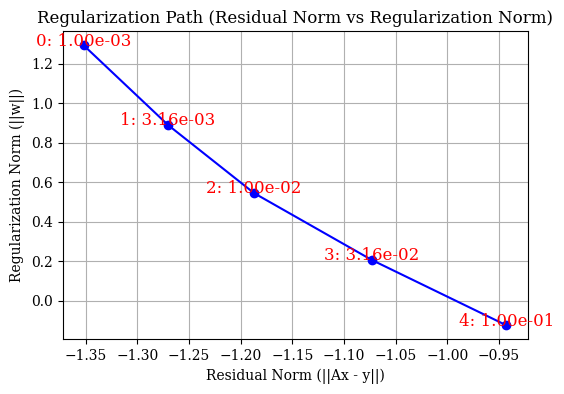

In [8]:
all_mat=org_m.A(b_matrix,db_x1_matrix,db_x2_matrix)
lamb_regu=np.logspace(-3, -1, 5, endpoint = True) # 10-5, 10-4.5,..., 10+0.5, 10+1
res,reg_norm,w_store=org_m.L_curve(all_mat,F,[],[],[],lamb_regu,"linear",device,cupy_device) #先进行求解

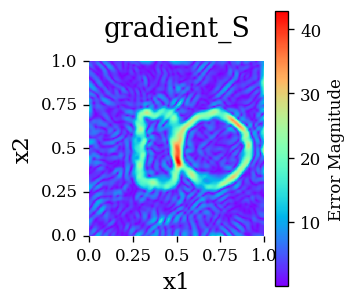

S_l_inf= 1.7240947344420847 S_L_2= 0.11648684114511902 S_l_2= 0.25790343837214036


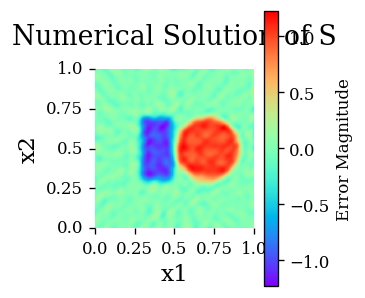

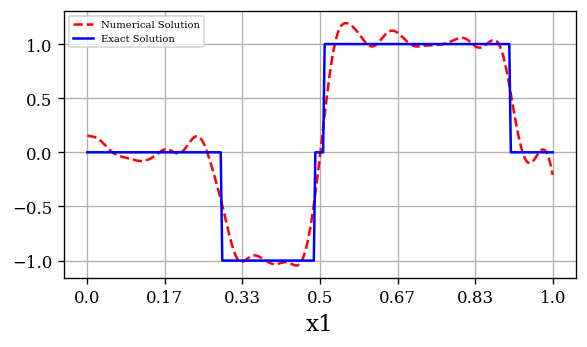

In [11]:
Qx=150
Qy=150
S_test_num,S_test_true,S_l_inf1,S_l_21,g_S=error_general_2D.test(model1,[],[],M,Qx,Qy,w_store[:,4],af,[],[],True,True,tau_x_min,tau_x_max,tau_y_min,tau_y_max,x_left,x_right,y_below,y_upper,center_true,r_true,ana_S,1,device)

In [9]:
M=1600
model_1600 = net_2D_fix2.pre_define(Nx,Ny,M,R_m,af,tau_x_min,tau_x_max,tau_y_min,tau_y_max,[],[],[],[],[],[],[],[],[],[],[],[],[],[],[],[],[],device)
num_batches_gauss=100 #高斯点的批次数
batch_number_mea=1 #测量点的批次数
grad_temp=0
S_basis,b_matrix,db_x1_matrix,db_x2_matrix,grads_y1,grads_y2=org_matrix_2D.residual_vector(model_1600,points_b,tau_x_min,tau_x_max,tau_y_min,tau_y_max,center_true,r_true,M,af,choose,mea,kk,number_appr,num_batches_gauss,batch_number_mea,grad_temp,device,cupy_device)

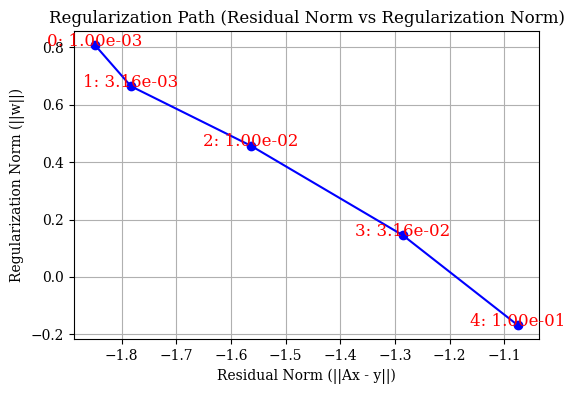

In [10]:
all_mat=org_m.A(b_matrix,db_x1_matrix,db_x2_matrix)
lamb_regu=np.logspace(-3, -1, 5, endpoint = True) # 10-5, 10-4.5,..., 10+0.5, 10+1
res,reg_norm,w_store=org_m.L_curve(all_mat,F,[],[],[],lamb_regu,"linear",device,cupy_device) #先进行求解

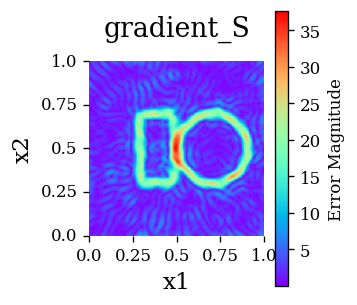

S_l_inf= 1.7337653281894085 S_L_2= 0.10567645787599199 S_l_2= 0.23396910392010387


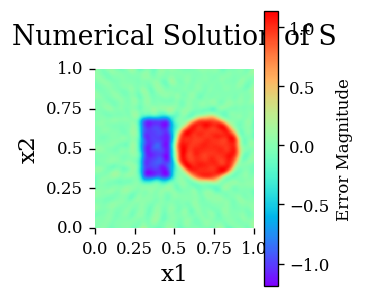

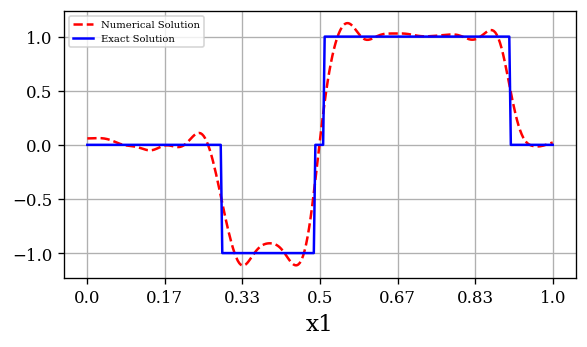

In [11]:
Qx=150
Qy=150
S_test_num,S_test_true,S_l_inf1,S_l_21,g_S=error_general_2D.test(model_1600,[],[],M,Qx,Qy,w_store[:,3],af,[],[],True,True,tau_x_min,tau_x_max,tau_y_min,tau_y_max,x_left,x_right,y_below,y_upper,center_true,r_true,ana_S,1,device)

In [12]:
M=3200
model_3200 = net_2D_fix2.pre_define(Nx,Ny,M,R_m,af,tau_x_min,tau_x_max,tau_y_min,tau_y_max,[],[],[],[],[],[],[],[],[],[],[],[],[],[],[],[],[],device)
num_batches_gauss=100 #高斯点的批次数
batch_number_mea=1 #测量点的批次数
grad_temp=0
S_basis,b_matrix,db_x1_matrix,db_x2_matrix,grads_y1,grads_y2=org_matrix_2D.residual_vector(model_3200,points_b,tau_x_min,tau_x_max,tau_y_min,tau_y_max,center_true,r_true,M,af,choose,mea,kk,number_appr,num_batches_gauss,batch_number_mea,grad_temp,device,cupy_device)

/mnt/store/hxw-y23/anaconda3/envs/inverse_source/lib/python3.9/site-packages/cupy/linalg/_solve.py:171: FutureWarning: `rcond` parameter will change to the default of machine precision times ``max(M, N)`` where M and N are the input matrix dimensions.
To use the future default and silence this warning we advise to pass `rcond=None`, to keep using the old, explicitly pass `rcond=-1`.
  warnings.warn(


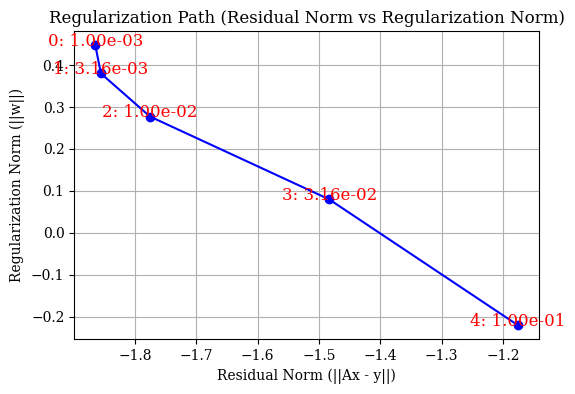

In [13]:
all_mat=org_m.A(b_matrix,db_x1_matrix,db_x2_matrix)
lamb_regu=np.logspace(-3, -1, 5, endpoint = True) # 10-5, 10-4.5,..., 10+0.5, 10+1
res,reg_norm,w_store=org_m.L_curve(all_mat,F,[],[],[],lamb_regu,"linear",device,cupy_device) #先进行求解

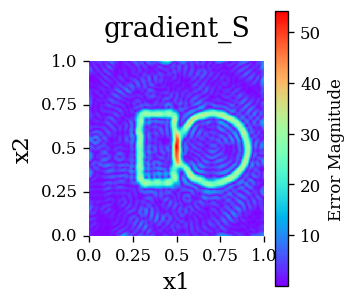

S_l_inf= 1.704844711993552 S_L_2= 0.09555000370732353 S_l_2= 0.21154899772661626


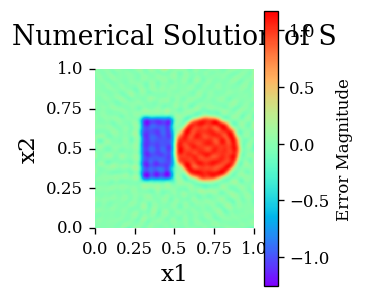

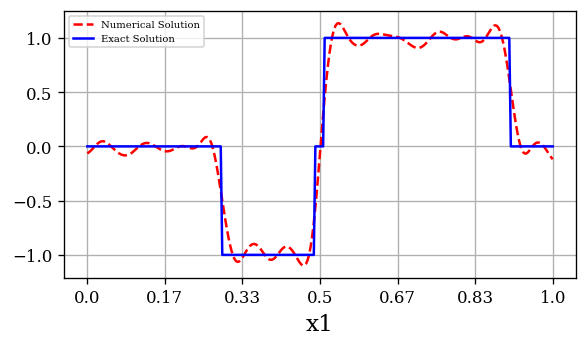

In [26]:
Qx=150
Qy=150
S_test_num,S_test_true,S_l_inf1,S_l_21,g_S=error_general_2D.test(model_3200,[],[],M,Qx,Qy,w_store[:,2],af,[],[],True,True,tau_x_min,tau_x_max,tau_y_min,tau_y_max,x_left,x_right,y_below,y_upper,center_true,r_true,ana_S,1,device)

In [14]:
M=6400
model_6400 = net_2D_fix2.pre_define(Nx,Ny,M,R_m,af,tau_x_min,tau_x_max,tau_y_min,tau_y_max,[],[],[],[],[],[],[],[],[],[],[],[],[],[],[],[],[],device)
num_batches_gauss=100 #高斯点的批次数
batch_number_mea=1 #测量点的批次数
grad_temp=0
S_basis,b_matrix,db_x1_matrix,db_x2_matrix,grads_y1,grads_y2=org_matrix_2D.residual_vector(model_6400,points_b,tau_x_min,tau_x_max,tau_y_min,tau_y_max,center_true,r_true,M,af,choose,mea,kk,number_appr,num_batches_gauss,batch_number_mea,grad_temp,device,cupy_device)

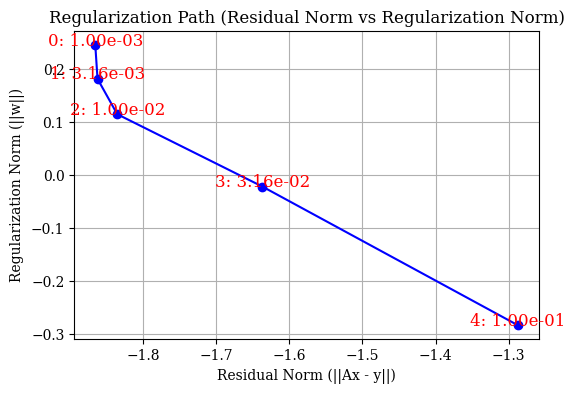

In [15]:
all_mat=org_m.A(b_matrix,db_x1_matrix,db_x2_matrix)
lamb_regu=np.logspace(-3, -1, 5, endpoint = True) # 10-5, 10-4.5,..., 10+0.5, 10+1
res,reg_norm,w_store=org_m.L_curve(all_mat,F,[],[],[],lamb_regu,"linear",device,cupy_device) #先进行求解

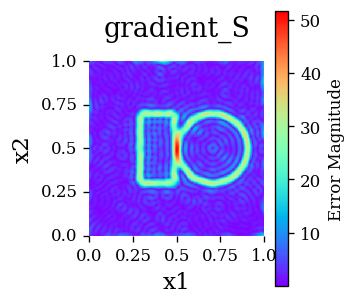

S_l_inf= 1.73094084808721 S_L_2= 0.09147969603017606 S_l_2= 0.20253728159757228


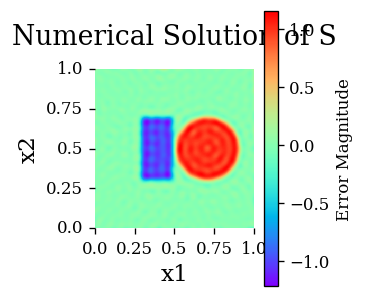

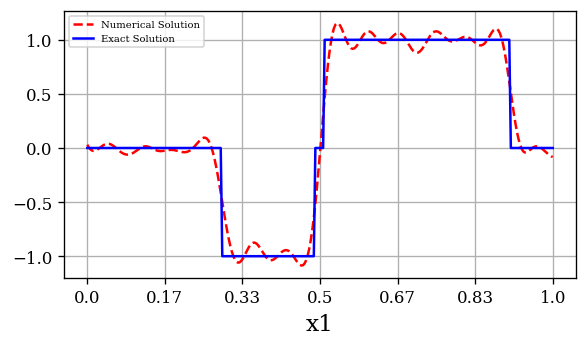

In [33]:
Qx=150
Qy=150
S_test_num,S_test_true,S_l_inf1,S_l_21,g_S=error_general_2D.test(model_6400,[],[],M,Qx,Qy,w_store[:,2],af,[],[],True,True,tau_x_min,tau_x_max,tau_y_min,tau_y_max,x_left,x_right,y_below,y_upper,center_true,r_true,ana_S,1,device)